# PCA

In [3]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np

def apply_pca(df, n_components):
    # Scale all features except the last column (0 to 1)
    scaler = MinMaxScaler() # purpose of assigning a varible to this Class is it stores Min, Max of particular df
    X_scaled = scaler.fit_transform(df.iloc[:, :-1])  # Scale all columns except the last one

    # Apply PCA
    pca = PCA(n_components=n_components)
    principal_components = pca.fit_transform(X_scaled)

    # Create a new DataFrame with PCA results
    pca_df = pd.DataFrame(principal_components, columns=[f'PC{i+1}' for i in range(n_components)])

    # Keep the last column (target) in the new DataFrame
    pca_df['Target'] = df.iloc[:, -1].values  
    # Get Eigenvalues (explained variance)
    eigenvalues = pca.explained_variance_

    # Get Eigenvectors (principal axes)
    eigenvectors = pca.components_

    unit_eigenvectors = eigenvectors / np.linalg.norm(eigenvectors, axis=1, keepdims=True)


    # Convert transformed data to DataFrame
    pca_df = pd.DataFrame(principal_components, columns=[f'PC{i+1}' for i in range(n_components)])

    return pca_df, pca.explained_variance_ratio_, eigenvalues, unit_eigenvectors

# PCA of Raw Data set:
input_file_path_new = "D:\\final_year_project\\final_export\\csv\\new\\training_parameters_postprocessing_new.csv"
df = pd.read_csv(input_file_path_new)
pca_df, variance_ratio, eigenvalues, eigenvectors = apply_pca(df, 20)
np.set_printoptions(precision=2, suppress=True)  # Set precision and avoid scientific notation for small values

print("PCA Transformed Data:\n", np.round(pca_df.head(), 2))
print("Shape of PCA Transformed Data:\n", pca_df.shape)
print("Explained Variance Ratio:", np.round(variance_ratio, 2))
print("Eigenvalues:", ["{:.2e}".format(val) for val in eigenvalues])
print("Eigenvectors:\n", np.array2string(eigenvectors, formatter={'float_kind': lambda x: "{:.2e}".format(x)}))

PCA Transformed Data:
     PC1   PC2   PC3   PC4   PC5   PC6   PC7   PC8   PC9  PC10  PC11  PC12  \
0  0.18 -0.59  0.24 -0.28  0.16  0.05  0.43  0.30  0.26 -0.08 -0.24 -0.20   
1  0.30 -0.51  0.14  0.57 -0.07 -0.32  0.19 -0.22 -0.42 -0.17  0.02 -0.50   
2 -0.83  0.09 -0.15  0.27  0.40  0.35  0.46  0.41 -0.14  0.19 -0.59 -0.07   
3  0.11 -0.03 -0.11  0.56 -0.12  0.30 -0.44 -0.24  0.25 -0.13 -0.50  0.13   
4  0.63  0.44 -0.24 -0.18 -0.08 -0.32  0.23  0.27 -0.57 -0.31  0.32  0.30   

   PC13  PC14  PC15  PC16  PC17  PC18  PC19  PC20  
0 -0.08  0.04 -0.05  0.04 -0.02 -0.01 -0.01  0.00  
1  0.21  0.06 -0.02  0.04 -0.03  0.00  0.00  0.01  
2 -0.04 -0.11 -0.03  0.01 -0.02 -0.02  0.01 -0.00  
3 -0.31 -0.06 -0.03 -0.07 -0.03  0.00  0.00 -0.00  
4  0.14 -0.39 -0.01 -0.04  0.00 -0.02 -0.01  0.00  
Shape of PCA Transformed Data:
 (198, 20)
Explained Variance Ratio: [0.19 0.13 0.1  0.07 0.06 0.06 0.06 0.05 0.05 0.05 0.05 0.04 0.04 0.03
 0.   0.   0.   0.   0.   0.  ]
Eigenvalues: ['3.13e-01', '2.22

# R2-Score v/s number of PC

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import pandas as pd

# Load the data
input_file_path = "D:\\final_year_project\\final_export\\csv\\new\\pca_transformed_data_scaled_new.csv"
df = pd.read_csv(input_file_path)

# Define target (y)
y = df.iloc[:, -1].values.reshape(-1, 1)  # The last column as target

# Scale target variable
scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y).flatten()

r2_PC = []
# Iterate through features incrementally
for i in range(1, df.shape[1]):  # Start from 1 feature up to all
    X = df.iloc[:, :i]  # Select first 'i' columns as features
    
    # Scale the selected features
    scaler_X = StandardScaler()
    X_scaled = scaler_X.fit_transform(X)

    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

    # Train the model
    model_pca = LinearRegression()
    model_pca.fit(X_train, y_train)

    # Predict and compute R² score
    y_pred_pca = model_pca.predict(X_test)
    r2 = r2_score(y_test, y_pred_pca)
    r2_PC.append(r2)

    print(f"R² Score with {i} feature(s): {r2:.4f}")  # Print R² score rounded to 4 decimals


R² Score with 1 feature(s): -0.0305
R² Score with 2 feature(s): -0.0390
R² Score with 3 feature(s): -0.0608
R² Score with 4 feature(s): -0.0688
R² Score with 5 feature(s): -0.0689
R² Score with 6 feature(s): -0.0715
R² Score with 7 feature(s): -0.1469
R² Score with 8 feature(s): -0.1574
R² Score with 9 feature(s): -0.1882
R² Score with 10 feature(s): -0.1930
R² Score with 11 feature(s): -0.1930
R² Score with 12 feature(s): -0.2143
R² Score with 13 feature(s): -0.2163
R² Score with 14 feature(s): -0.2254
R² Score with 15 feature(s): -0.2399
R² Score with 16 feature(s): -0.2925
R² Score with 17 feature(s): -0.3099
R² Score with 18 feature(s): -0.3098
R² Score with 19 feature(s): -0.4298


# R2 Scores vs Principle Components Visulization (arranged in descending order)

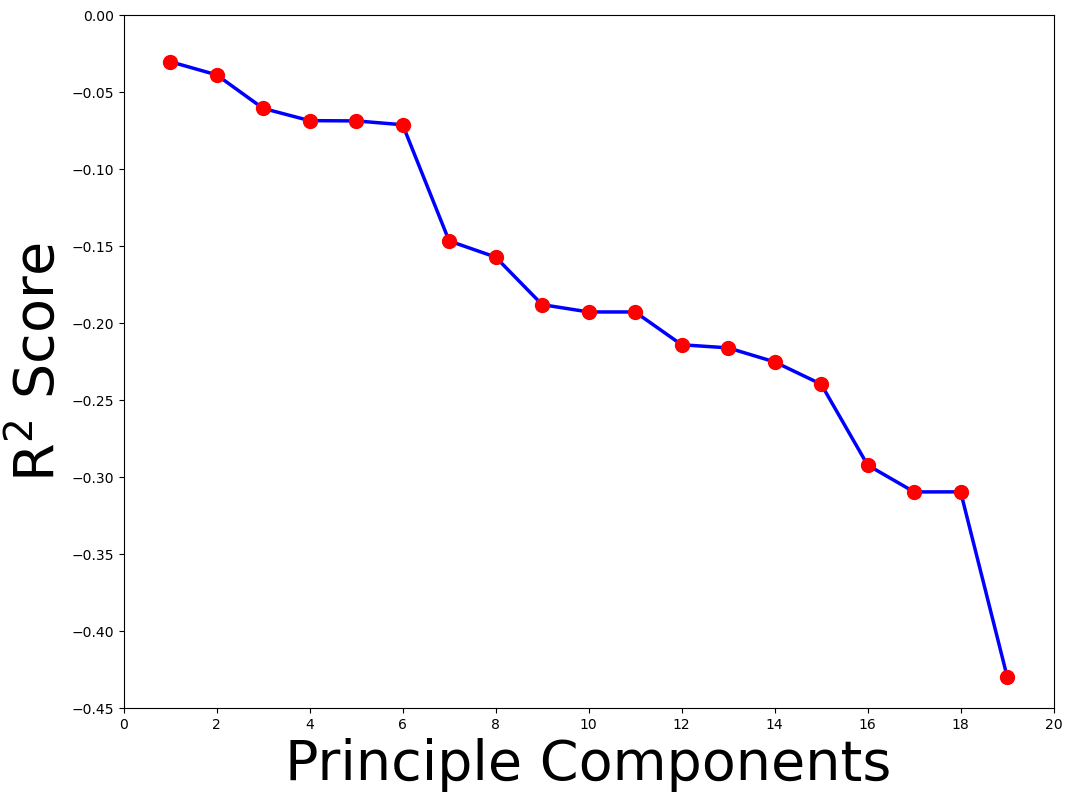

In [6]:
import matplotlib.pyplot as plt


num_features = list(range(1, df.shape[1]))  # Feature count list
# Plot R² Score vs. Number of Features
plt.figure(figsize=(12, 9))
plt.plot(num_features, r2_PC, marker='o', linestyle='-', color='b', label=r"$\mathrm{R^2\ Score}$", lw = 2.5, markersize = 10, 
        markerfacecolor = 'red', markeredgecolor = 'red')

plt.xlabel("Principle Components", fontsize=40)
plt.ylabel(r"$\mathrm{R^2\ Score}$", fontsize=40)
# plt.title("R² Score vs. Principle Components", fontsize=14, fontweight='bold', fontname="Times New Roman")
plt.xticks([i for i in range(0, 22, 2)])
plt.ylim(-0.45, 0)
# plt.yticks([i/10 for i in range(11)])

# plt.grid(True, linestyle='--', alpha=0.6)
# plt.legend()
output_file_path = "D:\\final_year_project\\final_export\\pics_after_sim\\new_analysis\\R2_score_vs_PC.png"
plt.savefig(output_file_path, dpi = 800)
plt.show()
